In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet34, ResNet34_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3 # 1=pet, 2=background, 3=border of the pet
EPOCHS = 15
ENCODER_LR = 1e-5
DECODER_LR = 1e-3
PATIENCE = 5
print(f"Using device: {DEVICE}")

Using device: cuda


## Data set

In [ ]:
# data transformations
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root = "./data", split="trainval", transform=None):
        self.base = OxfordIIITPet(
            root = root,
            split = split,
            target_types = "segmentation",
            download=True
        )
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = np.array(image)
        mask = np.array(mask).astype(np.int64) -1
        augmented = self.transform(image=image, mask = mask)
        image = augmented["image"]
        mask = torch.as_tensor(augmented["mask"],dtype=torch.long)
        return image, mask

## U-net

![architecture](resnet_unet_architecture.png)

stem, layer 1,2,3,4(bottle neck) are resnet34 layers

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv1 = nn.Conv2d(in_ch+skip_ch,out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch,kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
    def forward(self,x, skip):
        x = self.upsample(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [ ]:
# print(resnet34())

In [ ]:
class ResNetUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES):
        super().__init__()
        weights = ResNet34_Weights.DEFAULT
        resnet = resnet34(weights=weights)
        # Encoder
        # i/p img = 3ch, 128x128
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64ch 64x64
        self.pool = resnet.maxpool # 64ch 64x64
        self.layer1 = resnet.layer1 # 64ch 32x32
        self.layer2 = resnet.layer2 # 128ch 16x16
        self.layer3 = resnet.layer3 # 256ch 8x8
        self.bottleneck = resnet.layer4 # 512ch 4x4
        # Decoder
        self.decoder4 = DecoderBlock(in_ch = 512, skip_ch=256, out_ch = 256) # 256ch 8x8
        self.decoder3 = DecoderBlock(in_ch = 256, skip_ch=128, out_ch = 128) # 128ch 16x16
        self.decoder2 = DecoderBlock(in_ch = 128, skip_ch=64, out_ch=64) # 64ch 32x32
        self.decoder1 = DecoderBlock(in_ch = 64, skip_ch=64, out_ch=64)  # 64ch 64x64
        self.final_upsample = nn.Upsample(scale_factor=2, mode="nearest") # 64ch 128x128
        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1)
        ) # [num_classes ch 128x128]
    def forward(self,x):
        # Encoder pass
        x0 = self.stem(x)
        x1 = self.pool(x0)
        x1 = self.layer1(x1)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        # bottle neck pass
        x4= self.bottleneck(x3)
        # decoder pass
        d4 = self.decoder4(x4, x3)
        d3 = self.decoder3(d4, x2)
        d2 = self.decoder2(d3, x1)
        d1 = self.decoder1(d2, x0)

        out = self.final_upsample(d1)
        out = self.final_conv(out)
        return out
    def get_param_groups(self, encoder_lr = ENCODER_LR, decoder_lr = DECODER_LR):
        # split parameters into 2 groups for different learning rates
        encoder_params = list(self.stem.parameters()) + \
                        list(self.layer1.parameters())+\
                        list(self.layer2.parameters())+\
                        list(self.layer3.parameters())+\
                        list(self.bottleneck.parameters())
        decoder_params = list(self.decoder4.parameters())+\
                        list(self.decoder3.parameters())+\
                        list(self.decoder2.parameters())+\
                        list(self.decoder1.parameters())+\
                        list(self.final_conv.parameters())
        return [
            {"params":encoder_params,"lr":encoder_lr},
            {"params":decoder_params, "lr":decoder_lr}
        ]

## Metric - Intersection over union(IOU)

In [ ]:
@torch.no_grad()
def compute_iou(preds, masks, num_classes=NUM_CLASSES):
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds==cls)
        mask_cls = (masks==cls)
        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        if union==0:
            continue # class not present in the batch. skip it
        ious.append(intersection/union)
    return sum(ious)/len(ious) if ious else 0.0

# Training Loop

In [ ]:
def train():
    train_ds = PetSegmentationDataset(split="trainval", transform=train_transform)
    test_ds = PetSegmentationDataset(split="test", transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = ResNetUNet(in_channels=3,num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.get_param_groups())
    scheduler= optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_miou = 0.0
    best_val_loss = float("inf")
    epochs_no_improve = 0
    for epoch in range(1,EPOCHS+1):
        # train
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()*images.size(0)
        training_loss = running_loss/len(train_ds)
        scheduler.step()
        # validate
        model.eval()
        val_loss, val_iou, n_batches = 0.0, 0.0, 0
        with torch.no_grad():
            for images, masks in test_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                loss = criterion(logits,masks)
                preds = torch.argmax(logits, dim=1)

                val_loss += loss.item()*images.size(0)
                val_iou += compute_iou(preds, masks)
                n_batches +=1
        val_loss /= len(test_ds)
        val_iou /= n_batches
        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss = {training_loss:.4f} val_loss = {val_loss:.4f} val_mIOU = {val_iou:.4f}")
        # best model saving
        if val_iou>best_miou:
            best_miou = val_iou
            torch.save({"epoch":epoch, "model_state_dict":model.state_dict(),
                        "val_miou":val_iou}, "resnet_unet_best.pth")
        # early stop
        if val_loss<best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve>=PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}(no val_loss improvement for {PATIENCE} epochs).")
            break
    print(f"\nTraining Completed. Best val_mIoU = {best_miou:.4f}, best val_loss = {best_val_loss:.4f}")
    return model, test_ds

In [ ]:
model,test_ds  = train()

100%|██████████| 792M/792M [00:33<00:00, 23.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.4MB/s]


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 168MB/s]


Epoch [01/15] train_loss = 0.4249 val_loss = 0.2891 val_mIOU = 0.7267
Epoch [02/15] train_loss = 0.2931 val_loss = 0.2667 val_mIOU = 0.7270
Epoch [03/15] train_loss = 0.2649 val_loss = 0.2538 val_mIOU = 0.7344
Epoch [04/15] train_loss = 0.2477 val_loss = 0.2639 val_mIOU = 0.7357
Epoch [05/15] train_loss = 0.2343 val_loss = 0.2322 val_mIOU = 0.7569
Epoch [06/15] train_loss = 0.2263 val_loss = 0.2281 val_mIOU = 0.7524
Epoch [07/15] train_loss = 0.2185 val_loss = 0.2363 val_mIOU = 0.7464
Epoch [08/15] train_loss = 0.2099 val_loss = 0.2197 val_mIOU = 0.7646
Epoch [09/15] train_loss = 0.2021 val_loss = 0.2154 val_mIOU = 0.7702
Epoch [10/15] train_loss = 0.1954 val_loss = 0.2157 val_mIOU = 0.7692
Epoch [11/15] train_loss = 0.1905 val_loss = 0.2146 val_mIOU = 0.7727
Epoch [12/15] train_loss = 0.1867 val_loss = 0.2118 val_mIOU = 0.7731
Epoch [13/15] train_loss = 0.1821 val_loss = 0.2127 val_mIOU = 0.7690
Epoch [14/15] train_loss = 0.1799 val_loss = 0.2106 val_mIOU = 0.7728
Epoch [15/15] train_

## Visualization

In [ ]:
# back to original values
def denormalize(img_tensor):
    # normalized = (original - mean) / std -> original = normalized * std + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0,1)

In [ ]:
@torch.no_grad()
def visualize(model, dataset, n=4):
    model.eval()
    fig, axes = plt.subplots(n,3, figsize=(9, 3*n))
    for i in range(n):
        image, mask = dataset[i]
        logits = model(image.unsqueeze(0).to(DEVICE))  # model expects a batch size images
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu() # removes fake batch D
        axes[i,0].imshow(denormalize(image).permute(1,2,0))
        axes[i,0].set_title("Input Image")
        axes[i,1].imshow(mask,cmap="viridis",vmin=0, vmax=2)
        axes[i,1].set_title("Ground Truth Mask")
        axes[i,2].imshow(pred, cmap="viridis", vmin=0, vmax=2)
        axes[i,2].set_title("Predicted Mask")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

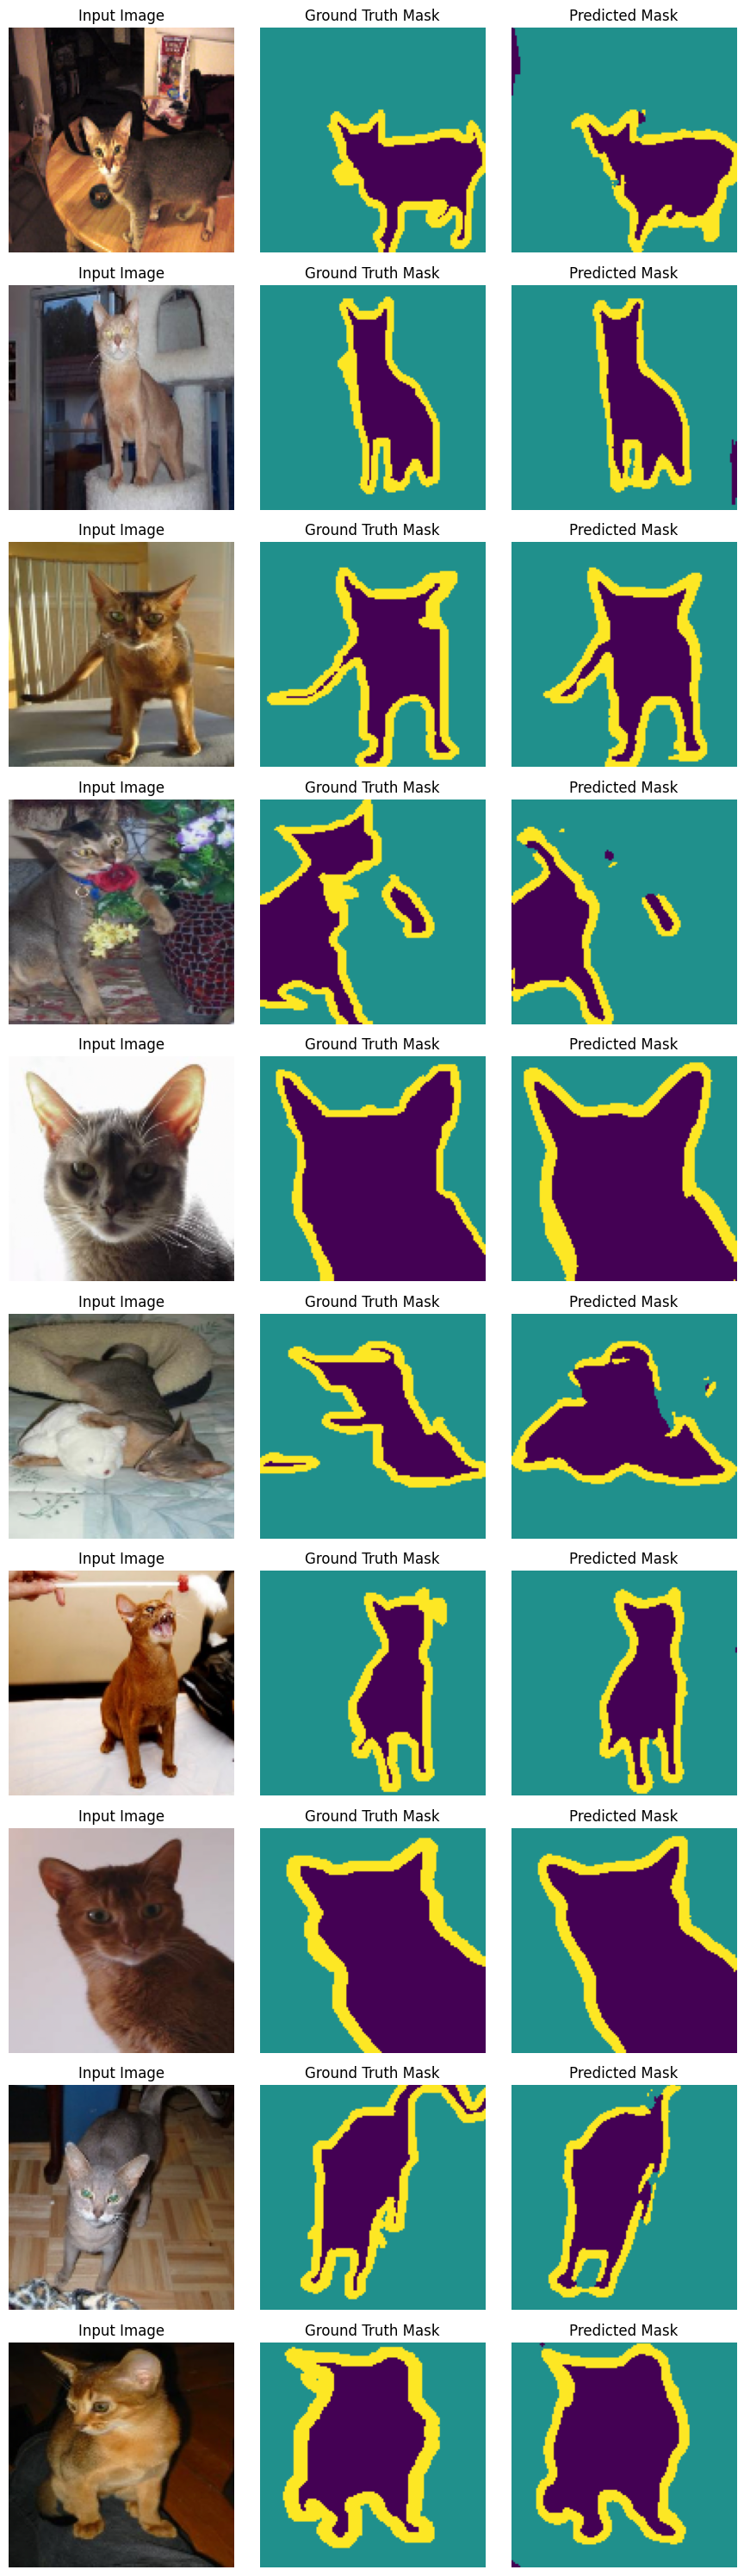

In [ ]:
visualize(model, test_ds, n=10)